In [36]:
import pandas as pd

df = pd.read_csv('aice_day8_customer_churn.csv')

In [25]:
df.head()

,customer_id,age,city,plan,contract,payment_method,tenure_months,monthly_fee,usage_hours,support_calls,late_payments,churn
0,C0001,59.0,Seoul,Standard,Monthly,Card,14,55.3,9.9,0,1,1
1,C0002,32.0,Seoul,Standard,Monthly,Mobile,70,46.5,51.0,0,3,0
2,C0003,29.0,Daegu,Basic,Monthly,Bank,14,34.5,46.2,2,0,0
3,C0004,65.0,Busan,Basic,Yearly,Card,71,34.0,65.1,1,0,0
4,C0005,23.0,Seoul,Basic,Monthly,Card,30,16.3,29.6,3,1,1


In [37]:
df.isnull().sum()

customer_id        0
age               10
city               8
plan               0
contract           0
payment_method     0
tenure_months      0
monthly_fee        7
usage_hours        5
support_calls      0
late_payments      0
churn              0
dtype: int64

In [5]:
df['churn'].value_counts()

churn
0    256
1     64
Name: count, dtype: int64

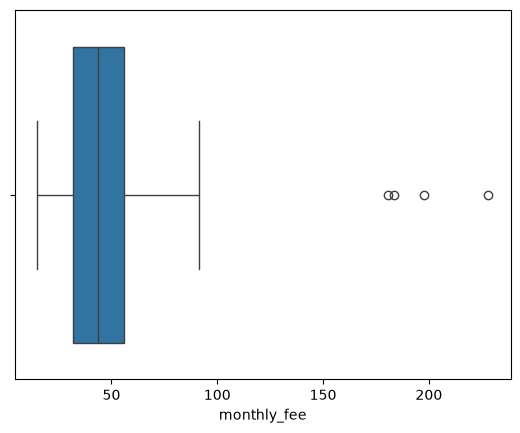

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df, x='monthly_fee')
plt.show()


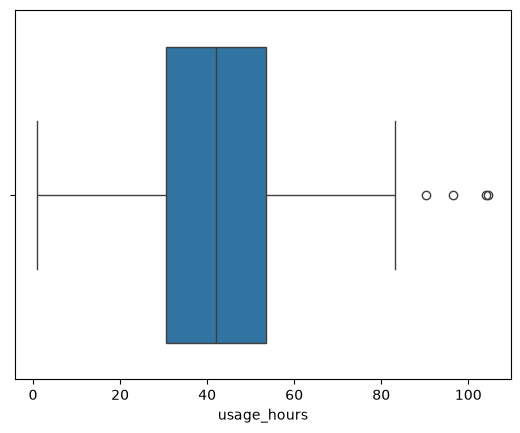

In [39]:
sns.boxplot(data=df, x='usage_hours')
plt.show()

In [41]:
# monthly_fee , usage_hours = 이상치 있음(median)
# age, tenure_months = 이상치 없음(mean)
df['monthly_fee'] = df['monthly_fee'].fillna(df['monthly_fee'].median())
df['usage_hours'] = df['usage_hours'].fillna(df['usage_hours'].median())
df['age'] = df['age'].fillna(df['age'].mean())
df['tenure_months'] = df['tenure_months'].fillna(df['tenure_months'].mean())

In [42]:
# 범주형 결측치 처리
df['city'] = df['city'].fillna(df['city'].mode().iloc[0])

In [43]:
df.isnull().sum()

customer_id       0
age               0
city              0
plan              0
contract          0
payment_method    0
tenure_months     0
monthly_fee       0
usage_hours       0
support_calls     0
late_payments     0
churn             0
dtype: int64

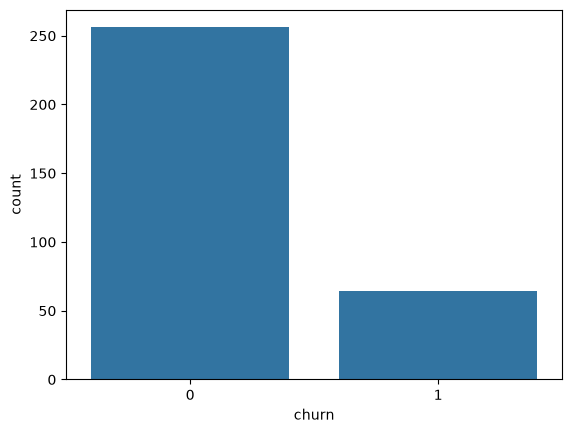

In [44]:
# churn 별 데이터 개수
sns.countplot(data=df, x='churn')
plt.show()

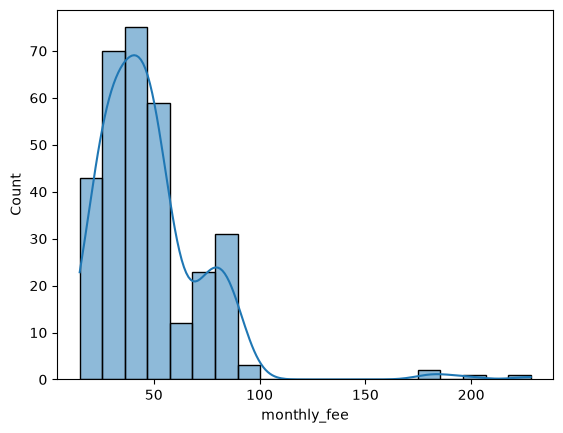

In [45]:
# monthly_fee 전체 분포
sns.histplot(data=df, x='monthly_fee', bins=20, kde=True)
plt.show()

In [46]:
df.head()

,customer_id,age,city,plan,contract,payment_method,tenure_months,monthly_fee,usage_hours,support_calls,late_payments,churn
0,C0001,59.0,Seoul,Standard,Monthly,Card,14,55.3,9.9,0,1,1
1,C0002,32.0,Seoul,Standard,Monthly,Mobile,70,46.5,51.0,0,3,0
2,C0003,29.0,Daegu,Basic,Monthly,Bank,14,34.5,46.2,2,0,0
3,C0004,65.0,Busan,Basic,Yearly,Card,71,34.0,65.1,1,0,0
4,C0005,23.0,Seoul,Basic,Monthly,Card,30,16.3,29.6,3,1,1


In [52]:
print(df['city'].value_counts())
print(df['payment_method'].value_counts())
print(df['plan'].value_counts())
print(df['contract'].value_counts())

city
Seoul      115
Busan       72
Daegu       48
Gwangju     43
Daejeon     42
Name: count, dtype: int64
payment_method
Card      112
Bank      105
Mobile    103
Name: count, dtype: int64
plan
Basic       132
Standard    127
Premium      61
Name: count, dtype: int64
contract
Monthly    229
Yearly      91
Name: count, dtype: int64


In [53]:
# 범주형 처리
df = pd.get_dummies(df, columns=['city', 'payment_method', 'plan'])
df['contract'] = df['contract'].map({'Monthly':0, 'Yearly': 1})

In [54]:
df.head()

,customer_id,age,contract,tenure_months,monthly_fee,usage_hours,support_calls,late_payments,churn,city_Busan,city_Daegu,city_Daejeon,city_Gwangju,city_Seoul,payment_method_Bank,payment_method_Card,payment_method_Mobile,plan_Basic,plan_Premium,plan_Standard
0,C0001,59.0,0,14,55.3,9.9,0,1,1,False,False,False,False,True,False,True,False,False,False,True
1,C0002,32.0,0,70,46.5,51.0,0,3,0,False,False,False,False,True,False,False,True,False,False,True
2,C0003,29.0,0,14,34.5,46.2,2,0,0,False,True,False,False,False,True,False,False,True,False,False
3,C0004,65.0,1,71,34.0,65.1,1,0,0,True,False,False,False,False,False,True,False,True,False,False
4,C0005,23.0,0,30,16.3,29.6,3,1,1,False,False,False,False,True,False,True,False,True,False,False


In [ ]:
# xy 분리
df = df.drop(columns=['customer_id'])

x = df.drop(columns=['churn'])
y = df['churn']

In [ ]:
# train/test
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# 스케일링(KNN을 위한 전처리)
from sklearn.preprocessing import StandardScaler

scaled = StandardScaler()

x_train_scaled = scaled.fit_transform(x_train)
x_test_scaled = scaled.transform(x_test)

In [62]:
# 후보 탐색
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

params = {
    'n_neighbors':[1, 3, 5, 7, 9, 11]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    params,
    cv=5,
    scoring='recall'
)


In [64]:
grid.fit(x_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'n_neighbors': 1}
0.09818181818181819


In [65]:
from sklearn.metrics import confusion_matrix, classification_report


pred = grid.predict(x_test_scaled)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[43  8]
 [ 9  4]]
              precision    recall  f1-score   support

           0       0.83      0.84      0.83        51
           1       0.33      0.31      0.32        13

    accuracy                           0.73        64
   macro avg       0.58      0.58      0.58        64
weighted avg       0.73      0.73      0.73        64



In [ ]:
from sklearn.linear_model import LogisticRegression

model_1 = LogisticRegression()
model_2 = LogisticRegression(class_weight='balanced')

model_1.fit(x_train_scaled, y_train)
model_2.fit(x_train_scaled, y_train)

pred_1 = model_1.predict(x_test_scaled)
pred_2 = model_2.predict(x_test_scaled)

# 실제 이탈 고객을 단 한명도 못찾음
print("model_1 : ")
print(confusion_matrix(y_test, pred_1))
print(classification_report(y_test, pred_1))

# accuracy가 낮더라도 실제 이탈 고객을 13명 중 9명 찾음
print("model_2 : ")
print(confusion_matrix(y_test, pred_2))
print(classification_report(y_test, pred_2))

model_1 : 
[[51  0]
 [13  0]]
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        51
           1       0.00      0.00      0.00        13

    accuracy                           0.80        64
   macro avg       0.40      0.50      0.44        64
weighted avg       0.64      0.80      0.71        64

model_2 : 
[[34 17]
 [ 4  9]]
              precision    recall  f1-score   support

           0       0.89      0.67      0.76        51
           1       0.35      0.69      0.46        13

    accuracy                           0.67        64
   macro avg       0.62      0.68      0.61        64
weighted avg       0.78      0.67      0.70        64



c:\Users\LSG\Desktop\AICE\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LSG\Desktop\AICE\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LSG\Desktop\AICE\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [80]:
proba = model_1.predict_proba(x_test_scaled)[:,1]
pred_th = (proba>=0.3).astype(int)

print(confusion_matrix(y_test, pred_th))
print(classification_report(y_test, pred_th))

[[49  2]
 [10  3]]
              precision    recall  f1-score   support

           0       0.83      0.96      0.89        51
           1       0.60      0.23      0.33        13

    accuracy                           0.81        64
   macro avg       0.72      0.60      0.61        64
weighted avg       0.78      0.81      0.78        64



In [ ]:
# 임계점 및 proba(지정 값(1)만 들고오는것) 연결
threshold = [0.2, 0.3, 0.4, 0.5]

for th in threshold:
    pred_for = (proba>=th).astype(int)

    print("threshold : ", th)
    print(confusion_matrix(y_test, pred_for))
    print(classification_report(y_test, pred_for))

threshold :  0.2
[[37 14]
 [ 6  7]]
              precision    recall  f1-score   support

           0       0.86      0.73      0.79        51
           1       0.33      0.54      0.41        13

    accuracy                           0.69        64
   macro avg       0.60      0.63      0.60        64
weighted avg       0.75      0.69      0.71        64

threshold :  0.3
[[49  2]
 [10  3]]
              precision    recall  f1-score   support

           0       0.83      0.96      0.89        51
           1       0.60      0.23      0.33        13

    accuracy                           0.81        64
   macro avg       0.72      0.60      0.61        64
weighted avg       0.78      0.81      0.78        64

threshold :  0.4
[[51  0]
 [12  1]]
              precision    recall  f1-score   support

           0       0.81      1.00      0.89        51
           1       1.00      0.08      0.14        13

    accuracy                           0.81        64
   macro avg       0

c:\Users\LSG\Desktop\AICE\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LSG\Desktop\AICE\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LSG\Desktop\AICE\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [85]:
# roc-auc 연결
from sklearn.metrics import roc_auc_score

proba_1 = model_1.predict_proba(x_test_scaled)[:,1]
proba_2 = model_2.predict_proba(x_test_scaled)[:,1]

print(roc_auc_score(y_test, proba_1))
print(roc_auc_score(y_test, proba_2))


0.6681749622926094
0.6455505279034691


In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

df2 = pd.read_csv('aice_day8_customer_churn.csv')

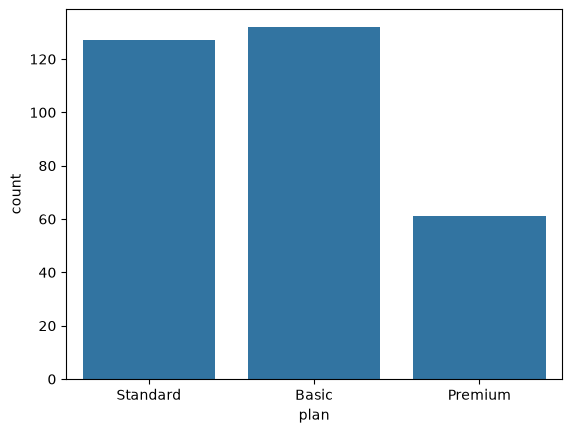

In [89]:
sns.countplot(data=df2, x='plan')
plt.show()

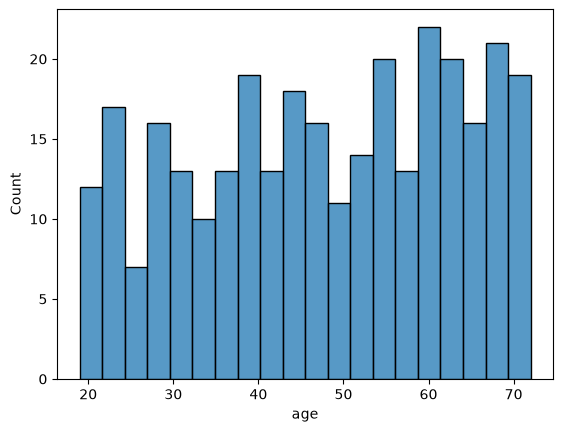

In [90]:
sns.histplot(data=df2, x='age', bins=20)
plt.show()


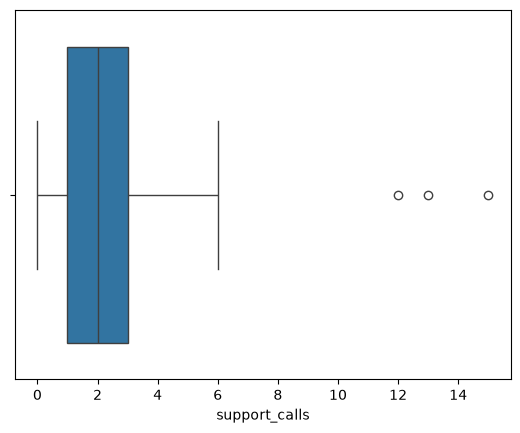

In [91]:
sns.boxplot(data=df2, x='support_calls')
plt.show()

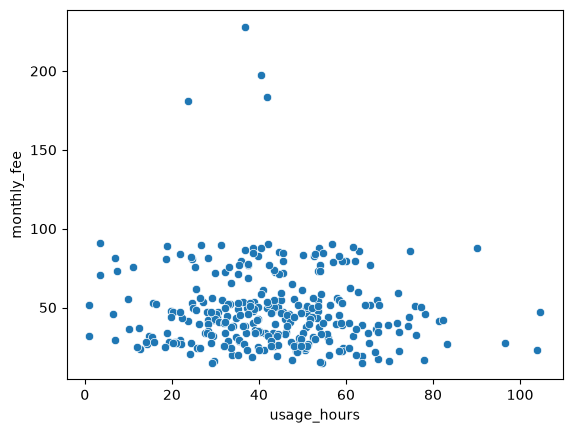

In [94]:
sns.scatterplot(data=df2, x='usage_hours', y='monthly_fee')
plt.show()

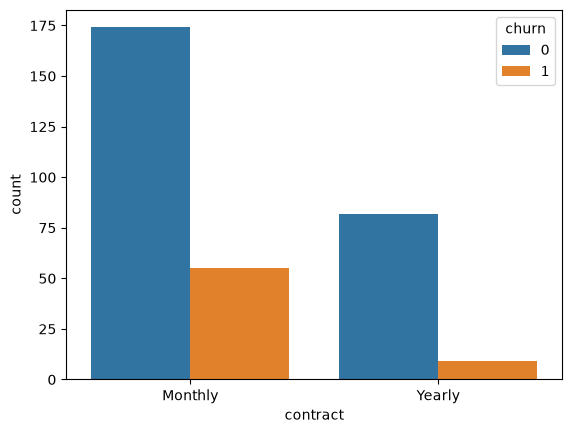

In [95]:
sns.countplot(data=df2, x='contract', hue='churn')
plt.show()

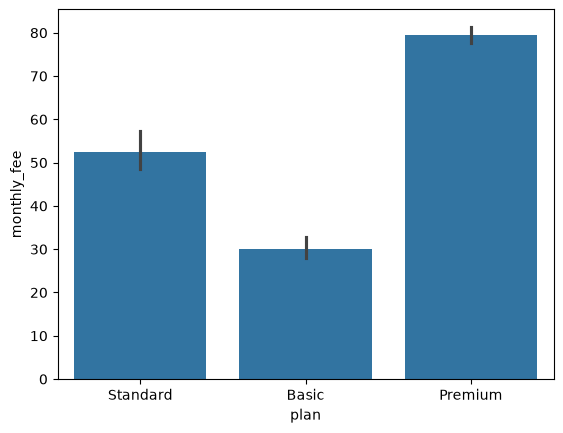

In [96]:
sns.barplot(data=df2, x='plan', y='monthly_fee')
plt.show()

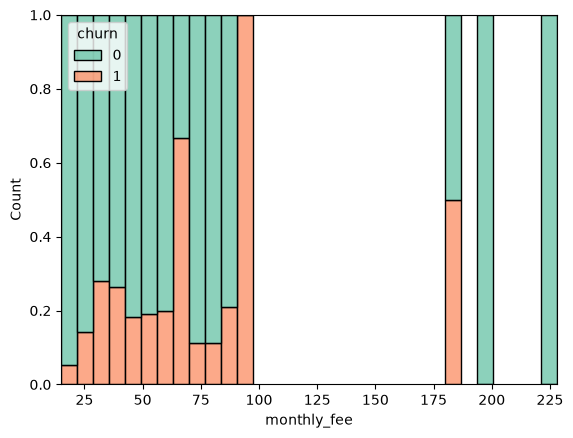

In [102]:
sns.histplot(data=df2, x='monthly_fee', multiple='fill', hue='churn', palette='Set2')
plt.show()